Try out different clustering models in the given dataset. Find the optimum number
of clusters in each model and create the model with the optimum number of
clusters.

Please note the following:

Display the output for every action

Create a repository in GitHub account as "Public"

Upload the notebook file(.ipynb) to the repository

Please make sure that you are uploading the notebook file including the outputs as well
Share the link of this notebook from GitHub in the online text editor provided in Paatshala

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('/content/Wine_clust.csv')
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
data.shape

(178, 13)

In [4]:
data.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [5]:
data.isna().sum()

,0
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


In [6]:
X=data.iloc[:,[1,2]].values
X

array([[1.71, 2.43],
       [1.78, 2.14],
       [2.36, 2.67],
       [1.95, 2.5 ],
       [2.59, 2.87],
       [1.76, 2.45],
       [1.87, 2.45],
       [2.15, 2.61],
       [1.64, 2.17],
       [1.35, 2.27],
       [2.16, 2.3 ],
       [1.48, 2.32],
       [1.73, 2.41],
       [1.73, 2.39],
       [1.87, 2.38],
       [1.81, 2.7 ],
       [1.92, 2.72],
       [1.57, 2.62],
       [1.59, 2.48],
       [3.1 , 2.56],
       [1.63, 2.28],
       [3.8 , 2.65],
       [1.86, 2.36],
       [1.6 , 2.52],
       [1.81, 2.61],
       [2.05, 3.22],
       [1.77, 2.62],
       [1.72, 2.14],
       [1.9 , 2.8 ],
       [1.68, 2.21],
       [1.5 , 2.7 ],
       [1.66, 2.36],
       [1.83, 2.36],
       [1.53, 2.7 ],
       [1.8 , 2.65],
       [1.81, 2.41],
       [1.64, 2.84],
       [1.65, 2.55],
       [1.5 , 2.1 ],
       [3.99, 2.51],
       [1.71, 2.31],
       [3.84, 2.12],
       [1.89, 2.59],
       [3.98, 2.29],
       [1.77, 2.1 ],
       [4.04, 2.44],
       [3.59, 2.28],
       [1.68,

In [7]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(3,9):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

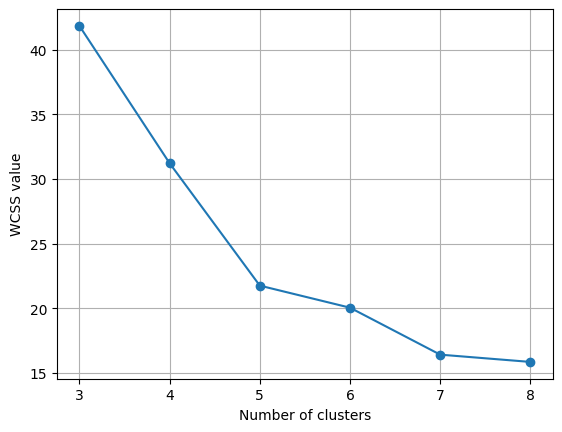

In [8]:
plt.plot(range(3,9),wcss,'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS value')
plt.grid()

In [9]:
kmeans1=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans1.fit_predict(X)

In [10]:
print(y_kmeans)

[2 2 3 2 3 2 2 2 2 0 2 2 2 2 2 2 2 2 2 3 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 0 1 2 1 2 1 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 2 0 0 0 0 0 2 2 2 2
 0 2 0 3 0 1 0 2 0 1 0 0 2 2 2 0 2 2 2 3 2 2 2 0 0 3 2 0 3 2 2 3 2 2 0 2 1
 3 3 0 2 2 0 2 1 1 3 2 1 4 1 2 2 2 2 1 0 3 3 1 0 3 4 4 1 3 3 3 3 4 1 1 4 4
 3 1 3 3 2 3 0 4 1 3 2 2 1 3 3 1 3 1 1 1 3 4 3 3 3 4 1 1 3 1]


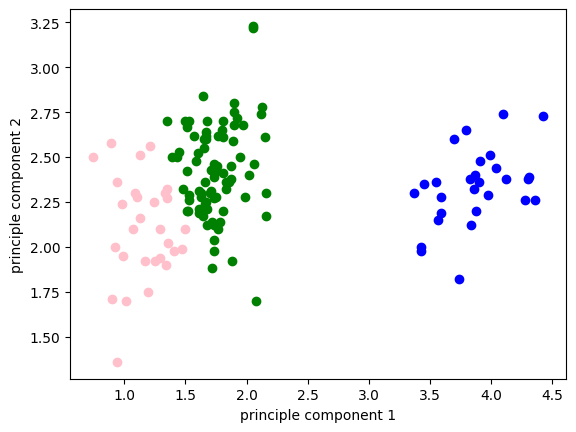

In [11]:
plt.scatter(X[y_kmeans==0,0],X[y_kmeans==0,1],c='pink',label='Cluster 1')
plt.scatter(X[y_kmeans==1,0],X[y_kmeans==1,1],c='blue',label='Cluster 2')
plt.scatter(X[y_kmeans==2,0],X[y_kmeans==2,1],c='green',label='Cluster 3')
plt.xlabel('principle component 1')
plt.ylabel('principle component 2')
plt.show()

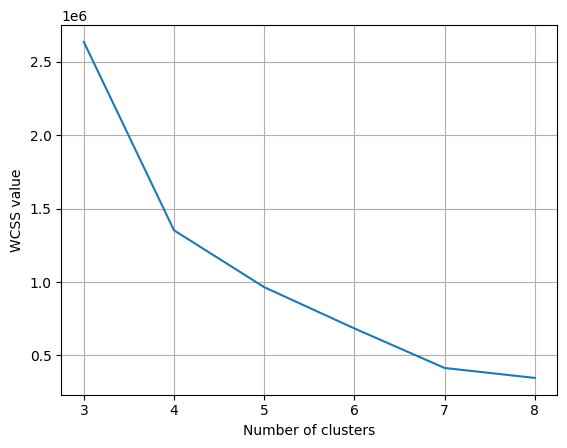

In [12]:
wcss=[]
for i in range(3,9):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(data)
  wcss.append(kmeans.inertia_)

plt.plot(range(3,9),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS value')
plt.grid()


In [13]:
kmeans2=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_kmeans2=kmeans2.fit_predict(data)
y_kmeans2

array([1, 1, 1, 2, 3, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 3, 3, 3,
       1, 1, 3, 3, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 3, 1, 1, 3, 3, 1, 1, 3,
       3, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 0, 3, 0, 3, 0, 0, 3,
       0, 0, 3, 3, 3, 0, 0, 1, 3, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0,
       3, 3, 0, 0, 0, 0, 0, 1, 3, 0, 3, 0, 3, 0, 0, 0, 3, 0, 0, 0, 0, 3,
       0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 3, 3, 3, 3, 0, 0, 3, 3, 3, 0, 0, 3, 3, 0, 3, 3, 0, 0, 0, 0, 3,
       3, 3, 0, 3, 3, 3, 0, 3, 0, 3, 3, 0, 3, 3, 3, 3, 0, 0, 3, 3, 3, 3,
       3, 0], dtype=int32)